# Проект. Исследование стартапов

## Введение

Цель данного проекта — провести комплексный анализ инвестиционного рынка на основе исторических данных, выявить ключевые тенденции и закономерности, а также сформировать обоснованные рекомендации для принятия инвестиционных решений. В рамках проекта анализируются:
- структура рынка и распределение компаний по сегментам;
- динамика объёмов финансирования и инвестиционной активности по годам;
- типичный размер инвестиционного раунда и его изменение во времени;
- различия между массовыми, средними и нишевыми сегментами;
- поведение аномальных значений и их влияние на результаты анализа;
- динамика возврата средств по различным типам финансирования.

Особое внимание уделяется очистке и подготовке данных, корректной работе с выбросами и фокусировке на периодах с достаточным уровнем инвестиционной активности. На основе полученных результатов формируются практические рекомендации о том, в какие отрасли и с использованием каких инструментов финансирования целесообразно инвестировать, если рассматривать рынок с позиции начала 2015 года.

## Шаг 1. Знакомство с данными: загрузка и предобработка

Датасет получен из базы данных стартапов.

Название основного датасета — `cb_investments.zip`. Внутри архива один файл — `cb_investments.csv`.

Описание данных:
* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Название дополнительного датасета — `cb_returns.csv`. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Описание данных:
* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.

### 1.1. Вывод общей информации

Загружаем необходимые для работы библиотеки.

In [2]:
# Работа с данными
import pandas as pd

# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns

Загружаем данные по проекту.

In [3]:
# Загрузка датасетов из локальной папки

cb_investments = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)
cb_returns = pd.read_csv('cb_returns.csv')

In [6]:
# Выводим первые строки датафрейма
cb_investments.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
# Выводим информацию о датафрейме
cb_investments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

В датасете cb_investments представлены данные о 54 тыс. компаний и 40 признаках.
Структура данных соответствует описанию, но часть столбцов требует предобработки.
В частности, столбец funding_total_usd имеет строковый тип и должен быть приведён к числовому, а столбцы с датами — к формату datetime.
Также присутствуют пропуски, часть из которых является ожидаемой (текстовые признаки), а часть требует обработки в рамках задач проекта (например, mid_funding_at).
В целом, объём и качество данных достаточны для решения поставленных аналитических задач.

In [5]:
# Выводим первые строки второго датафрейма
cb_returns.head()

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
1,2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2,2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
3,2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
4,2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


In [6]:
# Выводим информацию о датафрейме
cb_returns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


Датасет cb_returns содержит данные о возвратах средств по различным типам финансирования в разрезе лет. В таблице представлено 15 наблюдений и 14 признаков, где каждый ряд соответствует отдельному году. Столбец year имеет целочисленный тип данных и полностью заполнен, остальные столбцы содержат числовые значения (float64) и также не имеют пропусков. Типы данных соответствуют содержимому столбцов, приведение типов или дополнительная предобработка на данном этапе не требуется.

### 1.2. Предобработка данных

В ходе предобработки было выявлено, что в датасете cb_investments названия столбцов market и funding_total_usd содержат ведущие пробелы, что может приводить к ошибкам при обращении к данным. Для корректной работы с датафреймом пробелы в названиях всех столбцов следует удалить. В остальном названия столбцов оформлены в едином стиле snake_case, корректно отражают содержимое признаков и не требуют дополнительного переименования или изменений.

In [7]:
# Удаляем ведущие и замыкающие пробелы из названий столбцов
cb_investments.columns = cb_investments.columns.str.strip()

Названия компаний (name) и сегментов рынка (market) необходимо привести к единому формату: удалить пробелы в начале и конце строк, все значения перевести в нижний регистр, а пробелы заменить на символ подчёркивания. Это позволит избежать дублирования значений, вызванного различиями в написании, и упростит дальнейшие группировки и подсчёты.

In [8]:
# Приводим столбцы market и name к единому стилю
for col in ['market', 'name']:
    cb_investments[col] = (
        cb_investments[col]
        .astype(str)          # на случай NaN / нестроковых значений
        .str.strip()          # убираем пробелы в начале и конце
        .str.lower()          # переводим в нижний регистр
        .str.replace(' ', '_', regex=False)  # заменяем пробелы на _
    )

In [9]:
cb_investments['market'].value_counts()

market
nan              8817
software         5489
biotechnology    3761
mobile           2725
e-commerce       2283
                 ... 
creative            1
distribution        1
musicians           1
hotels              1
gold                1
Name: count, Length: 440, dtype: int64

Столбец funding_total_usd содержит числовые значения в строковом формате с разделителями разрядов, что не позволяет выполнять числовые операции. В рамках предобработки разделители разрядов необходимо удалить и привести столбец к числовому типу для дальнейшего анализа.

In [10]:
# Убираем разделители разрядов и приводим к числовому типу
cb_investments['funding_total_usd'] = (
    cb_investments['funding_total_usd']
    .astype('string')
    .str.replace(',', '', regex=False)
)

cb_investments['funding_total_usd'] = pd.to_numeric(
    cb_investments['funding_total_usd'],
    errors='coerce'
)

Необходимо привести к типу datetime столбцы founded_at, first_funding_at, mid_funding_at и last_funding_at, поскольку они будут использоваться для расчёта временных интервалов, анализа сроков финансирования и исследования динамики показателей. Столбцы founded_month и founded_quarter содержат агрегированную информацию в строковом формате и не планируются к использованию в дальнейших вычислениях, а столбец founded_year уже представлен в удобном числовом виде, поэтому дополнительного преобразования этих признаков не требуется и они будут оставлены без изменений.

In [12]:
# Приводим к типу datetime только те столбцы, которые будут использоваться
# для расчёта временных интервалов и анализа динамики
date_columns = [
    'founded_at',
    'first_funding_at',
    'mid_funding_at',
    'last_funding_at'
]

for col in date_columns:
    cb_investments[col] = pd.to_datetime(
        cb_investments[col],
        errors='coerce'
    )

В датасете cb_returns необходимо использовать столбец year в качестве индекса датафрейма, поскольку данные представлены в виде временного ряда с годовой агрегацией. Это позволит упростить работу с динамикой показателей, выполнение выборок по годам и построение временных графиков в дальнейших этапах анализа.

In [13]:
# Делаем столбец year индексом датафрейма
cb_returns = cb_returns.set_index('year')

В рамках предобработки будет выполнен анализ текстовых признаков. Пропуски будут заполнены заглушками только в тех столбцах, которые используются в дальнейшем анализе и группировках. В частности, для столбца market пропущенные значения будут заменены заглушкой, так как данный признак используется при анализе сегментов рынка. Пропуски в остальных текстовых столбцах не оказывают влияния на решение задач проекта и не требуют обязательной обработки.

In [14]:
# Заполняем пропуски в столбце market заглушкой
cb_investments['market'] = cb_investments['market'].fillna('unknown')

# Фиксируем исходные сегменты рынка (после базовой очистки)
cb_investments['market_raw'] = cb_investments['market']

Далее необходимо удалить полные дубликаты строк, так как они не несут дополнительной информации и могут искажать результаты анализа. Также требуется исключить из датасета компании, для которых отсутствуют данные в столбце funding_total_usd, поскольку данный признак является ключевым для дальнейшего исследования объёмов инвестиций и анализа рынка стартапов.

In [15]:
# Удаляем полные дубликаты строк
cb_investments = cb_investments.drop_duplicates()

# Удаляем строки без данных о финансировании
cb_investments = cb_investments.dropna(subset=['funding_total_usd'])

Заполняем пропуски в столбце mid_funding_at на основании значений в столбцах first_funding_at и last_funding_at. В качестве нового значения для пропусков будет использована приблизительная середина интервала между датами первого и последнего раундов финансирования. После выполнения заполнения требуется оценить количество и долю оставшихся пропусков в столбце, чтобы определить полноту данных и понять, насколько корректно удалось восстановить временную информацию о финансировании компаний.

In [16]:
# Заполняем пропуски в mid_funding_at серединой интервала между first_funding_at и last_funding_at
mask = (
    cb_investments['mid_funding_at'].isna()
    & cb_investments['first_funding_at'].notna()
    & cb_investments['last_funding_at'].notna()
)

cb_investments.loc[mask, 'mid_funding_at'] = (
    cb_investments.loc[mask, 'first_funding_at']
    + (cb_investments.loc[mask, 'last_funding_at'] - cb_investments.loc[mask, 'first_funding_at']) / 2
)

# Оцениваем размер оставшихся пропусков в mid_funding_at
missing_mid = cb_investments['mid_funding_at'].isna().sum()
missing_mid_share = cb_investments['mid_funding_at'].isna().mean()

print(f"Осталось пропусков в mid_funding_at: {missing_mid} ({missing_mid_share:.2%})")

Осталось пропусков в mid_funding_at: 1 (0.00%)


В результате заполнения пропусков в столбце mid_funding_at на основе значений first_funding_at и last_funding_at практически все отсутствующие значения были восстановлены. После предобработки в столбце остался один пропуск, что составляет менее 0.01% наблюдений и не оказывает существенного влияния на дальнейший анализ.

После выполнения всех этапов предобработки необходимо оценить полноту полученного датасета и сделать предварительный вывод о том, достаточно ли данных для решения задач проекта. Для этого будет сравнен размер исходного датасета с размером датасета после удаления полных дубликатов и строк без данных о финансировании. На основе этого сравнения будет рассчитан процент отброшенных наблюдений. Полученные значения позволят оценить, насколько значимыми оказались потери данных и можно ли считать оставшийся объём информации репрезентативным для дальнейшего анализа рынка стартапов.

In [17]:
# Исходное количество строк до предобработки (из info())
initial_rows = 54294

# Текущее количество строк после предобработки
final_rows = cb_investments.shape[0]

# Расчёт количества и доли отброшенных данных
dropped_rows = initial_rows - final_rows
dropped_share = dropped_rows / initial_rows * 100

print(f"Отброшено строк: {dropped_rows} ({dropped_share:.2f}%)")

Отброшено строк: 13387 (24.66%)


В ходе предобработки данные были приведены к корректному виду для дальнейшего анализа. Названия столбцов унифицированы, столбец funding_total_usd очищен от разделителей разрядов и приведён к числовому типу. К формату datetime были приведены только те столбцы с датами, которые используются для расчёта временных интервалов и анализа динамики финансирования. Пропуски в текстовых данных были обработаны выборочно: заглушка добавлена только в столбец market, так как он участвует в сегментации рынка.

Также были удалены полные дубликаты и строки без данных о финансировании. Пропуски в mid_funding_at были заполнены серединой интервала между датами первого и последнего раундов финансирования; после этого в столбце остался один пропуск, не оказывающий существенного влияния на анализ. В результате предобработки было отброшено 13 387 строк (24,66%), при этом оставшегося объёма данных достаточно для решения задач проекта.

## Шаг 2. Инжиниринг признаков

### 2.1. Группы по срокам финансирования

В рамках данного этапа инжиниринга признаков необходимо разделить все компании на три группы в зависимости от сроков финансирования: компании с единичным раундом финансирования, компании со сроком финансирования до одного года и компании со сроком финансирования более года. Для этого будет рассчитана продолжительность финансирования как разница между датами первого и последнего раундов финансирования. 

На основе полученной группировки требуется визуализировать распределение компаний между группами, показав долю каждой группы от общего числа компаний, а также проанализировать распределение привлечённых инвестиций, отобразив, какую часть общего объёма финансирования получила каждая из выделенных групп.

In [18]:
# Рассчитываем срок финансирования в днях
cb_investments['funding_duration_days'] = (
    cb_investments['last_funding_at'] - cb_investments['first_funding_at']
).dt.days

In [19]:
# Создаём признак с группами по срокам финансирования
cb_investments['funding_period_group'] = 'more_than_year'

# Единичное финансирование
cb_investments.loc[
    cb_investments['funding_rounds'] == 1,
    'funding_period_group'
] = 'single_round'

# Срок финансирования до года
cb_investments.loc[
    (cb_investments['funding_rounds'] > 1) &
    (cb_investments['funding_duration_days'] <= 365),
    'funding_period_group'
] = 'up_to_year'

In [20]:
# выводим результат группировки по срокам финансирования
cb_investments['funding_period_group'].value_counts()

funding_period_group
single_round      24113
more_than_year    12293
up_to_year         4501
Name: count, dtype: int64

- Визуализация распределения по количеству компаний

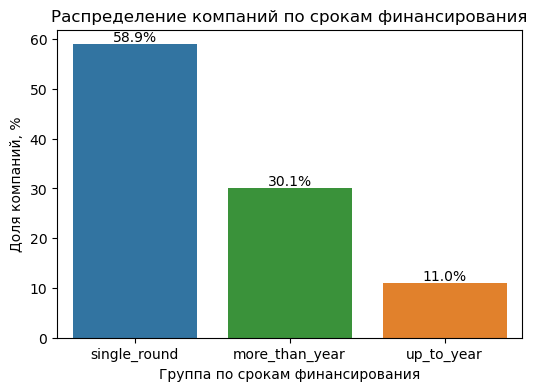

In [21]:
# Фиксируем цвета для каждой группы сроков финансирования
palette = {
    'single_round': '#1f77b4',     # синий
    'up_to_year': '#ff7f0e',       # оранжевый
    'more_than_year': '#2ca02c'    # зелёный
}

# Считаем долю компаний в каждой группе (в процентах)
companies_share = (
    cb_investments['funding_period_group']
    .value_counts(normalize=True)
    .mul(100)
    .rename('share')
    .reset_index()
    .rename(columns={'index': 'funding_period_group'})
)

plt.figure(figsize=(6, 4))

ax = sns.barplot(
    data=companies_share,
    x='funding_period_group',
    y='share',
    hue='funding_period_group',
    palette=palette,
    legend=False
)

# Добавляем подписи значений над столбцами
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='edge')

plt.ylabel('Доля компаний, %')
plt.xlabel('Группа по срокам финансирования')
plt.title('Распределение компаний по срокам финансирования')

plt.show()

- Визуализация распределения по объёму инвестиций

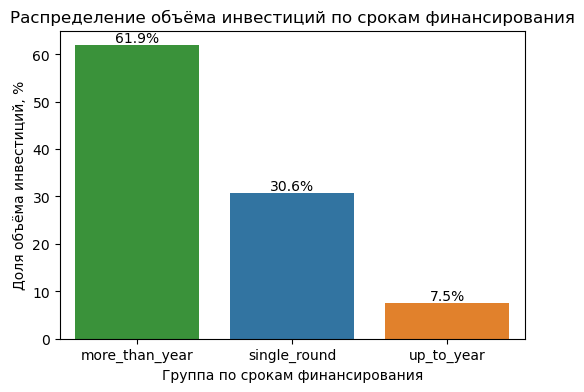

In [22]:
# Считаем суммарный объём инвестиций по группам
investments_share = (
    cb_investments
    .groupby('funding_period_group', as_index=False)['funding_total_usd']
    .sum()
)

# Считаем долю каждой группы от общего объёма инвестиций (в процентах)
investments_share['share'] = (
    investments_share['funding_total_usd']
    / investments_share['funding_total_usd'].sum()
    * 100
)

plt.figure(figsize=(6, 4))

# Строим график с фиксированными цветами для каждой категории
ax = sns.barplot(
    data=investments_share,
    x='funding_period_group',
    y='share',
    hue='funding_period_group',
    palette=palette,
    legend=False
)

# Добавляем подписи значений над столбцами
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='edge')

# Подписываем оси и заголовок
plt.ylabel('Доля объёма инвестиций, %')
plt.xlabel('Группа по срокам финансирования')
plt.title('Распределение объёма инвестиций по срокам финансирования')

plt.show()

Большинство компаний на рынке стартапов привлекают финансирование в рамках одного раунда: на их долю приходится около 59% всех компаний. При этом компании с длительным сроком финансирования (более года) составляют около 30% от общего числа, а компании со сроком финансирования до года — лишь около 11%. 

Распределение объёма инвестиций выглядит иначе: более 60% всех привлечённых средств приходится на компании с длительным сроком финансирования, тогда как компании с единичным раундом получают около 31% общего объёма инвестиций. Это указывает на то, что наиболее значительные объёмы финансирования концентрируются в компаниях, которые привлекают инвестиции на протяжении длительного времени, несмотря на то что по количеству они уступают стартапам с единичным раундом.

### 2.2 Выделение средних и нишевых сегментов рынка

На данном этапе будет выполнен подсчёт количества компаний, относящихся к каждому сегменту рынка, указанному в столбце market. На основе полученных значений все сегменты будут разделены на три категории в зависимости от их представленности в датасете: массовые сегменты, в которых представлено более 120 компаний, средние сегменты с числом компаний от 35 до 120 включительно, а также нишевые сегменты, включающие до 35 компаний. 

После этого будет определено, сколько сегментов попадает в каждую из указанных категорий, что позволит оценить структуру рынка с точки зрения разнообразия и концентрации сегментов. Для наглядного анализа распределения построен график, отображающий распределение сегментов по количеству компаний, с визуальным выделением границ между нишевыми, средними и массовыми сегментами.

In [23]:
# Считаем количество компаний в каждом сегменте рынка (по исходному market_raw)
market_counts = (
    cb_investments['market_raw']
    .value_counts()
    .rename('companies_count')
    .reset_index()
    .rename(columns={'index': 'market_raw'})
)

# Функция для определения типа сегмента
def segment_type(count):
    if count > 120:
        return 'mass'
    elif count >= 35:
        return 'mid'
    else:
        return 'niche'

# Добавляем категорию сегмента
market_counts['segment_type'] = market_counts['companies_count'].apply(segment_type)

In [24]:
# Маппинг: market_raw -> segment_type
market_group_map = market_counts.set_index('market_raw')['segment_type']

# Добавляем market_group в основной датафрейм
cb_investments['market_group'] = cb_investments['market_raw'].map(market_group_map)

In [25]:
# Считаем общее количество компаний в каждом типе сегмента
companies_by_segment = (
    market_counts
    .groupby('segment_type', as_index=False)['companies_count']
    .sum()
    .rename(columns={'companies_count': 'total_companies'})
)

companies_by_segment

,segment_type,total_companies
0,mass,36236
1,mid,3841
2,niche,830


In [26]:
# Считаем количество сегментов в каждой категории
segment_distribution = market_counts['segment_type'].value_counts()

segment_distribution

segment_type
niche    289
mid       57
mass      49
Name: count, dtype: int64

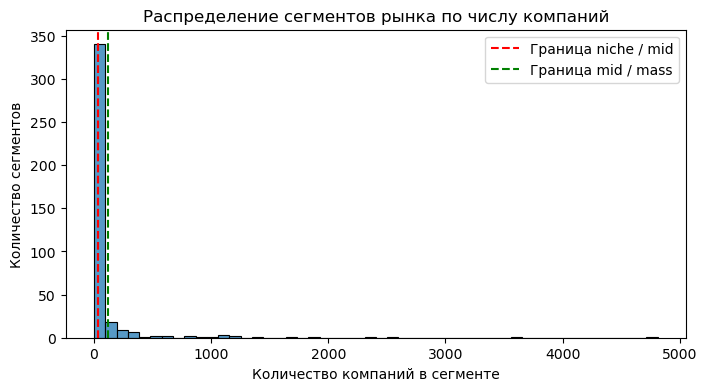

In [27]:
plt.figure(figsize=(8, 4))

sns.histplot(
    data=market_counts,
    x='companies_count',
    bins=50
)

# Вертикальные линии — границы между нишевыми и средними сегментами
plt.axvline(35, color='red', linestyle='--', label='Граница niche / mid')
plt.axvline(120, color='green', linestyle='--', label='Граница mid / mass')

plt.xlabel('Количество компаний в сегменте')
plt.ylabel('Количество сегментов')
plt.title('Распределение сегментов рынка по числу компаний')
plt.legend()

plt.show()

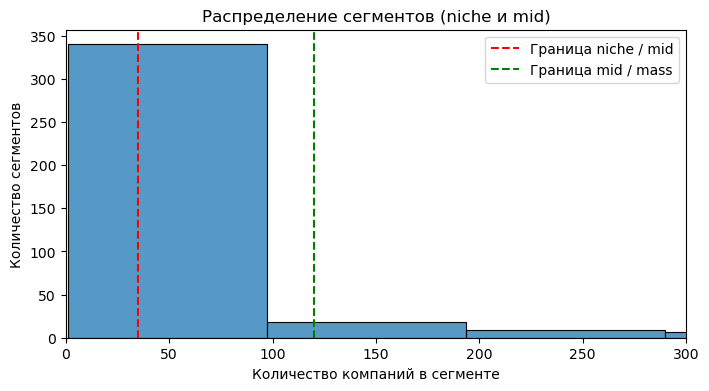

In [28]:
plt.figure(figsize=(8, 4))

sns.histplot(
    data=market_counts,
    x='companies_count',
    bins=50
)

plt.xlim(0, 300)  # фокус на niche + mid

plt.axvline(35, color='red', linestyle='--', label='Граница niche / mid')
plt.axvline(120, color='green', linestyle='--', label='Граница mid / mass')

plt.xlabel('Количество компаний в сегменте')
plt.ylabel('Количество сегментов')
plt.title('Распределение сегментов (niche и mid)')
plt.legend()

plt.show()

На первом графике показано распределение всех сегментов рынка по количеству компаний. Он демонстрирует общую картину рынка и позволяет увидеть сильную асимметрию распределения: подавляющее большинство сегментов включает небольшое число компаний, тогда как лишь несколько сегментов являются массовыми и объединяют тысячи компаний. Этот график наглядно иллюстрирует наличие длинного «хвоста» и высокую концентрацию компаний в ограниченном числе сегментов.

На втором графике отображено распределение сегментов только в диапазоне нишевых и средних сегментов. Он построен для повышения наглядности, так как массовые сегменты существенно искажают масштаб и мешают детальному анализу основной массы сегментов. Такой подход позволяет чётко визуализировать границу между нишевыми и средними сегментами и обосновывает дальнейшее объединение сегментов в укрупнённые категории (niche, mid, mass) для последующего анализа.

In [29]:
# Создаём словарь: реальный сегмент рынка (market_raw) -> укрупнённая категория (mass/mid/niche)
market_mapping = market_counts.set_index('market_raw')['segment_type']

# Записываем результат в новый столбец market_group, НЕ перезаписывая market/market_raw
cb_investments['market_group'] = cb_investments['market_raw'].map(market_mapping)

# Проверка результата
cb_investments['market_group'].value_counts()

market_group
mass     36236
mid       3841
niche      830
Name: count, dtype: int64

In [30]:
# Шаг по заданию: оставляем в market только массовые сегменты,
# остальные заменяем на заглушки 'mid' и 'niche'
cb_investments['market'] = cb_investments['market_raw']
cb_investments.loc[cb_investments['market_group'] != 'mass', 'market'] = cb_investments['market_group']

# Проверка: в market должны быть 'mid', 'niche' и N массовых сегментов
cb_investments['market'].nunique(), cb_investments['market'].value_counts().head(10)

(51,
 market
 software               4812
 mid                    3841
 biotechnology          3590
 nan                    2503
 mobile                 2344
 e-commerce             1866
 curated_web            1693
 enterprise_software    1381
 health_care            1185
 clean_technology       1180
 Name: count, dtype: int64)

После классификации реальных сегментов рынка по степени представленности было определено, что основная часть компаний относится к массовым сегментам — 36 236 компаний. В средние сегменты попадают 3 841 компания, тогда как нишевые сегменты представлены значительно меньшим числом компаний — 830. Это подтверждает высокую концентрацию компаний в ограниченном числе массовых рынков и существенную фрагментацию менее представленных сегментов.

В соответствии с заданием столбец market был преобразован: для массовых сегментов сохранены их исходные названия, а все средние и нишевые сегменты заменены на заглушки mid и niche.
В результате в столбце market осталось 51 уникальное значение: 49 массовых сегментов и 2 агрегированные категории (mid, niche), что соответствует требованиям задания и снижает фрагментацию данных для дальнейшего анализа.

## Шаг 3. Работа с выбросами и анализ

### 3.1. Анализируем и помечаем выбросы в каждом из сегментов


Проанализируем распределение общего объёма финансирования компаний в разрезе рыночных сегментов и определим типичный для рассматриваемого периода размер финансирования. С помощью графического анализа будут выявлены выбивающиеся значения, а также обозначен интервал, в котором сосредоточено большинство наблюдений, что позволит в дальнейшем формально определить выбросы и учесть их при анализе.

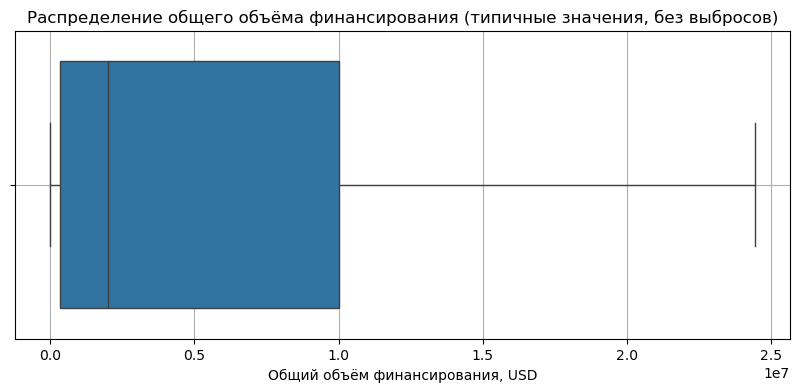

In [32]:
# Boxplot общего объёма финансирования (без группировок)
# showfliers=False — фокус на типичных значениях

plt.figure(figsize=(10, 4))

sns.boxplot(
    data=cb_investments,
    x='funding_total_usd',
    showfliers=False
)

plt.xlabel('Общий объём финансирования, USD')
plt.title('Распределение общего объёма финансирования (типичные значения, без выбросов)')
plt.grid(True)
plt.show()

По boxplot без отображения выбросов видно, что типичный размер общего финансирования для одной компании находится примерно до 25 млн USD, а значения выше можно считать выбивающимися относительно основной массы наблюдений.

- Далее необходимо выявить компании с аномальным объёмом общего финансирования, используя метод межквартильного размаха (IQR) отдельно для каждого укрупнённого сегмента рынка. После определения аномальных значений требуется рассчитать долю компаний с таким финансированием в каждом сегменте рынка и определить сегменты с наибольшей концентрацией аномально профинансированных компаний.

In [33]:
# IQR-границы и выбросы по уникальным значениям в market (mass-сегменты + mid/niche)

# 0) Убираем старые границы, если они уже есть (чтобы не появлялись lower_bound_x / lower_bound_y)
for col in ['lower_bound', 'upper_bound']:
    if col in cb_investments.columns:
        cb_investments = cb_investments.drop(columns=col)

# 1) (опционально, но полезно) Убираем пустые market (NaN и строку 'nan')
cb_investments = cb_investments[
    cb_investments['market'].notna() & (cb_investments['market'] != 'nan')
].copy()

# 2) Считаем границы IQR по каждому значению market
q = (
    cb_investments
    .groupby('market')['funding_total_usd']
    .quantile([0.25, 0.75])
    .unstack()
    .rename(columns={0.25: 'q1', 0.75: 'q3'})
)

q['iqr'] = q['q3'] - q['q1']
q['lower_bound'] = q['q1'] - 1.5 * q['iqr']
q['upper_bound'] = q['q3'] + 1.5 * q['iqr']

# 3) Присоединяем границы к строкам датафрейма
cb_investments = cb_investments.merge(
    q[['lower_bound', 'upper_bound']],
    left_on='market',
    right_index=True,
    how='left'
)

# 4) Помечаем выбросы
cb_investments['is_outlier'] = (
    (cb_investments['funding_total_usd'] < cb_investments['lower_bound']) |
    (cb_investments['funding_total_usd'] > cb_investments['upper_bound'])
)

# 5) Считаем долю выбросов по market и выводим топ
outliers_share = (
    cb_investments
    .groupby('market', as_index=False)
    .agg(
        total_companies=('funding_total_usd', 'size'),
        outliers_count=('is_outlier', 'sum')
    )
)

outliers_share['outliers_share'] = outliers_share['outliers_count'] / outliers_share['total_companies']

outliers_share.sort_values('outliers_share', ascending=False).head(15)

,market,total_companies,outliers_count,outliers_share
36,real_estate,279,48,0.172043
14,entertainment,150,25,0.166667
8,consulting,349,58,0.166189
38,search,291,48,0.164948
7,cloud_computing,152,25,0.164474
34,photography,204,33,0.161765
37,saas,272,44,0.161765
46,technology,238,38,0.159664
48,video,188,30,0.159574
32,niche,830,132,0.159036


Анализ доли выбросов по сегментам market показывает, что наибольшая относительная доля аномально крупных сделок наблюдается в ряде массовых сегментов, таких как real estate, entertainment, consulting, search и cloud computing. Это указывает на высокую неоднородность распределения объёмов финансирования внутри данных сегментов и заметное влияние отдельных крупных сделок на общую структуру рынка.
При этом для агрегированной категории niche доля выбросов сопоставима с отдельными массовыми сегментами, что отражает высокую фрагментированность и вариативность инвестиционной активности в нишевых рынках.

### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

На данном этапе будет проверена полнота данных за 2014 год на основе количества зафиксированных раундов финансирования. Далее из датасета будут исключены компании с аномальным объёмом финансирования, выявленные на предыдущем шаге. После этого в анализе будут оставлены только те компании, которые получали финансирование в годы с высокой инвестиционной активностью, определяемой как не менее 50 раундов финансирования в год. Такой подход позволяет ограничить анализ периодами с достаточной полнотой данных и снизить влияние нерепрезентативных наблюдений.

- Проверяем полноту данных за 2014 год на основе количества зафиксированных раундов финансирования

In [34]:
# Проверяем полноту 2014 года по распределению дат по месяцам
date_cols = ['founded_at', 'first_funding_at', 'mid_funding_at', 'last_funding_at']

monthly_2014 = {}

for col in date_cols:
    # Берём только даты 2014 года
    s_2014 = cb_investments.loc[cb_investments[col].dt.year == 2014, col]
    
    # Считаем количество записей по месяцам
    monthly_2014[col] = (
        s_2014.dt.to_period('M')
        .value_counts()
        .sort_index()
    )

# Собираем в одну таблицу (строки — месяцы, столбцы — тип даты)
monthly_2014_df = pd.DataFrame(monthly_2014).fillna(0).astype(int)
monthly_2014_df

,founded_at,first_funding_at,mid_funding_at,last_funding_at
2014-01,377,717,652,1087
2014-02,99,565,530,877
2014-03,97,600,609,1010
2014-04,90,529,577,1010
2014-05,66,491,540,974
2014-06,62,556,627,1098
2014-07,40,598,617,1180
2014-08,25,479,510,1016
2014-09,23,466,476,1059
2014-10,13,401,406,1036


Для проверки полноты данных за 2014 год была проанализирована помесячная динамика записей по ключевым датам (founded_at, first_funding_at, mid_funding_at, last_funding_at). Данные присутствуют во всех месяцах года, включая декабрь. Несмотря на ожидаемое сезонное снижение активности в ноябре–декабре, записи не обрываются и сохраняются по всем типам дат. Это позволяет считать данные за 2014 год полными и корректными для дальнейшего анализа.

In [35]:
# гарантируем, что дата — datetime
cb_investments['mid_funding_at'] = pd.to_datetime(cb_investments['mid_funding_at'], errors='coerce')

# гарантируем, что funding_year существует
cb_investments['funding_year'] = cb_investments['mid_funding_at'].dt.year

# 1) Исключаем компании с аномальным финансированием
cb_no_outliers = cb_investments.loc[~cb_investments['is_outlier']].copy()

# 2) Год финансирования
cb_no_outliers['funding_year'] = cb_no_outliers['mid_funding_at'].dt.year

rounds_by_year_raw = (
    cb_investments
    .groupby('funding_year')['funding_rounds']
    .sum()
    .reset_index(name='total_rounds')
    .sort_values('funding_year')
)

# 3) Раунды по годам после очистки
rounds_by_year_clean = (
    cb_no_outliers
    .groupby('funding_year')['funding_rounds']
    .sum()
    .reset_index(name='total_rounds')
    .sort_values('funding_year')
)

# 4) "Активные" годы (>= 50 раундов)
active_years = rounds_by_year_clean.loc[
    rounds_by_year_clean['total_rounds'] >= 50,
    'funding_year'
]

# 5) Оставляем компании только из активных лет
cb_filtered = cb_no_outliers.loc[
    cb_no_outliers['funding_year'].isin(active_years)
].copy()

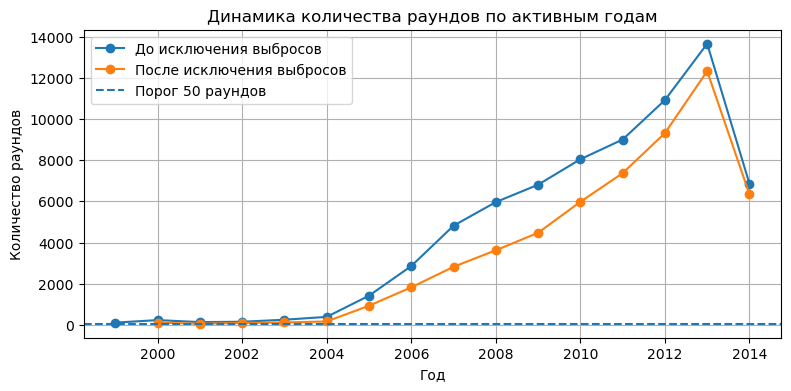

In [36]:
# Оставляем только годы с достаточной активностью (>= 50 раундов)
rounds_raw_active = rounds_by_year_raw[
    rounds_by_year_raw['total_rounds'] >= 50
]

rounds_clean_active = rounds_by_year_clean[
    rounds_by_year_clean['total_rounds'] >= 50
]

plt.figure(figsize=(9, 4))

plt.plot(
    rounds_raw_active['funding_year'],
    rounds_raw_active['total_rounds'],
    marker='o',
    label='До исключения выбросов'
)

plt.plot(
    rounds_clean_active['funding_year'],
    rounds_clean_active['total_rounds'],
    marker='o',
    label='После исключения выбросов'
)

plt.axhline(50, linestyle='--', label='Порог 50 раундов')

plt.xlabel('Год')
plt.ylabel('Количество раундов')
plt.title('Динамика количества раундов по активным годам')
plt.grid(True)
plt.legend()
plt.show()

График показывает динамику количества раундов финансирования по годам, ограниченную активными годами (не менее 50 раундов в год). Видно устойчивый рост инвестиционной активности, особенно после 2005 года, с пиком в 2013 году. Исключение компаний с аномальным финансированием снижает абсолютное количество раундов, однако не меняет общей динамики рынка, что подтверждает устойчивость выявленного тренда.

### 3.3. Анализ типов финансирования по объёму и популярности

На данном этапе планируется проанализировать типы финансирования с точки зрения как суммарного объёма привлечённых средств, так и частоты их использования компаниями. Для этого будут построены отдельные визуализации, отражающие общий объём инвестиций по каждому типу финансирования и количество компаний, применявших соответствующие инструменты.

Сопоставление полученных результатов позволит выявить типы финансирования, которые используются наиболее часто, но характеризуются сравнительно небольшими объёмами инвестиций, а также те формы финансирования, которые встречаются реже, но обеспечивают значительные объёмы привлечённого капитала.

- Подготовка списка типов финансирования

In [37]:
# Список столбцов с типами финансирования
funding_types = [
    'seed',
    'venture',
    'equity_crowdfunding',
    'undisclosed',
    'convertible_note',
    'debt_financing',
    'angel',
    'grant',
    'private_equity',
    'post_ipo_equity',
    'post_ipo_debt',
    'secondary_market',
    'product_crowdfunding'
]

- График по суммарному объёму финансирования

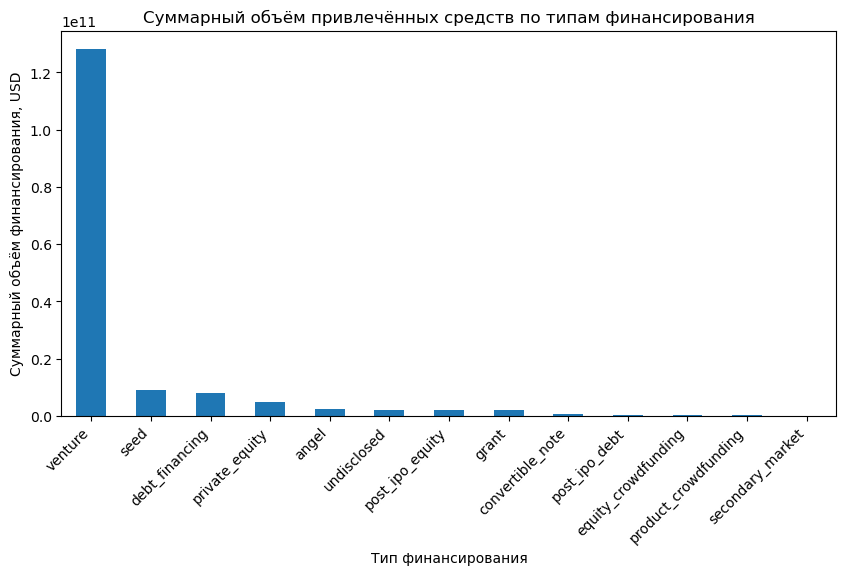

In [38]:
# Считаем суммарный объём привлечённых средств по каждому типу финансирования
funding_volume = (
    cb_filtered[funding_types]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

funding_volume.plot(kind='bar')

plt.ylabel('Суммарный объём финансирования, USD')
plt.xlabel('Тип финансирования')
plt.title('Суммарный объём привлечённых средств по типам финансирования')
plt.xticks(rotation=45, ha='right')

plt.show()

- График по популярности типов финансирования

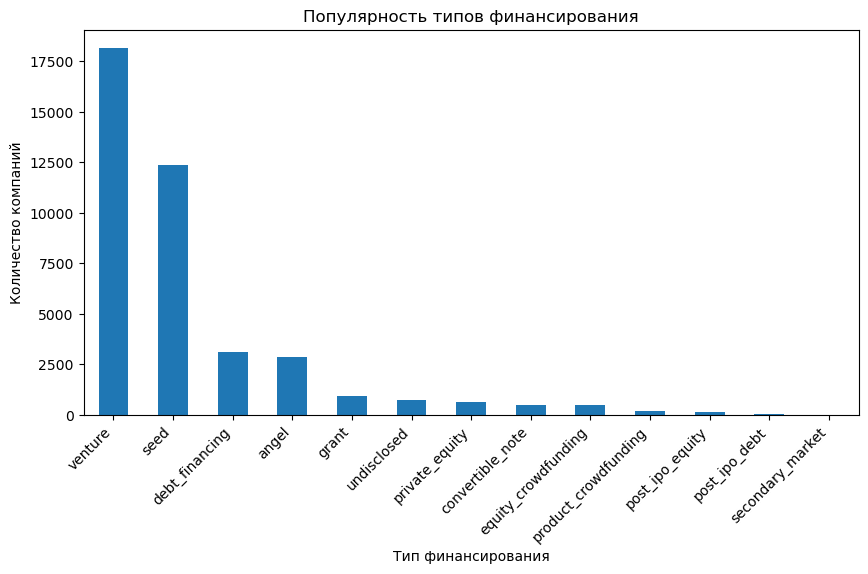

In [39]:
# Считаем, сколько раз каждый тип финансирования используется
funding_popularity = (
    (cb_filtered[funding_types] > 0)
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

funding_popularity.plot(kind='bar')

plt.ylabel('Количество компаний')
plt.xlabel('Тип финансирования')
plt.title('Популярность типов финансирования')
plt.xticks(rotation=45, ha='right')

plt.show()

Анализ суммарного объёма привлечённых средств показывает, что наибольшая часть инвестиций приходится на венчурное финансирование (venture) — этот тип существенно опережает остальные по общему объёму вложенных средств. При этом seed-финансирование и долговое финансирование (debt financing) также занимают заметное место, но с большим отрывом от лидера.

График популярности типов финансирования демонстрирует, что наиболее часто используемыми являются venture и seed — они встречаются в датасете значительно чаще других типов. В то же время такие формы, как private equity, post-IPO equity/debt и secondary market, используются относительно редко, однако при этом характеризуются крупными объёмами привлечённых средств.

Сопоставление графиков показывает, что venture- и seed-финансирование являются массовыми и широко распространёнными инструментами привлечения капитала, тогда как некоторые менее популярные типы финансирования играют важную роль в обеспечении крупных инвестиций для ограниченного числа компаний, как правило находящихся на более зрелых стадиях развития.

- Суммарные объёмы возвратов по типам финансирования

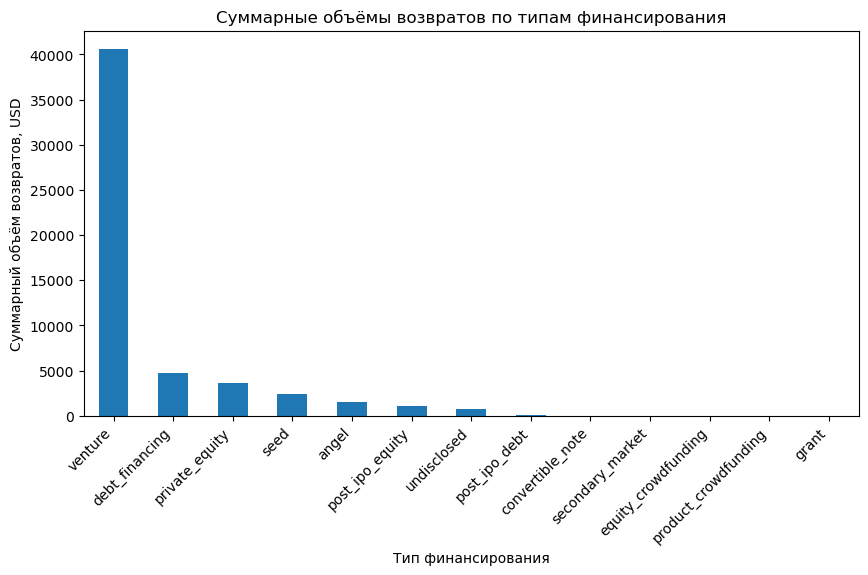

In [40]:
# Считаем суммарные объёмы возвратов за весь период
returns_volume = (
    cb_returns[funding_types]
    .sum()
    .sort_values(ascending=False)
)

# Строим график
plt.figure(figsize=(10, 5))

returns_volume.plot(kind='bar')

plt.ylabel('Суммарный объём возвратов, USD')
plt.xlabel('Тип финансирования')
plt.title('Суммарные объёмы возвратов по типам финансирования')
plt.xticks(rotation=45, ha='right')

plt.show()

Суммарные объёмы возвратов средств существенно различаются в зависимости от типа финансирования. Наибольшая доля возвратов приходится на венчурное финансирование (venture), что согласуется с его лидирующей ролью по объёму привлечённых инвестиций. Заметные объёмы возвратов также демонстрируют долговое финансирование (debt financing) и private equity, несмотря на их меньшую распространённость по сравнению с venture и seed. В то же время такие типы финансирования, как crowdfunding, convertible note и grant, характеризуются крайне низкими суммарными возвратами, что отражает либо небольшие объёмы вложений, либо специфику этих инструментов.

In [41]:
# Объединяем объём и популярность в одну таблицу
funding_compare = (
    funding_volume
    .rename('total_funding')
    .to_frame()
    .join(funding_popularity.rename('companies_count'))
)

funding_compare

,total_funding,companies_count
venture,1.281119e+11,18139
seed,9.110755e+09,12349
debt_financing,8.010603e+09,3097
private_equity,4.810806e+09,618
angel,2.440582e+09,2863
undisclosed,2.034127e+09,741
post_ipo_equity,1.942102e+09,163
grant,1.913027e+09,918
convertible_note,5.504268e+08,501
post_ipo_debt,2.867183e+08,27


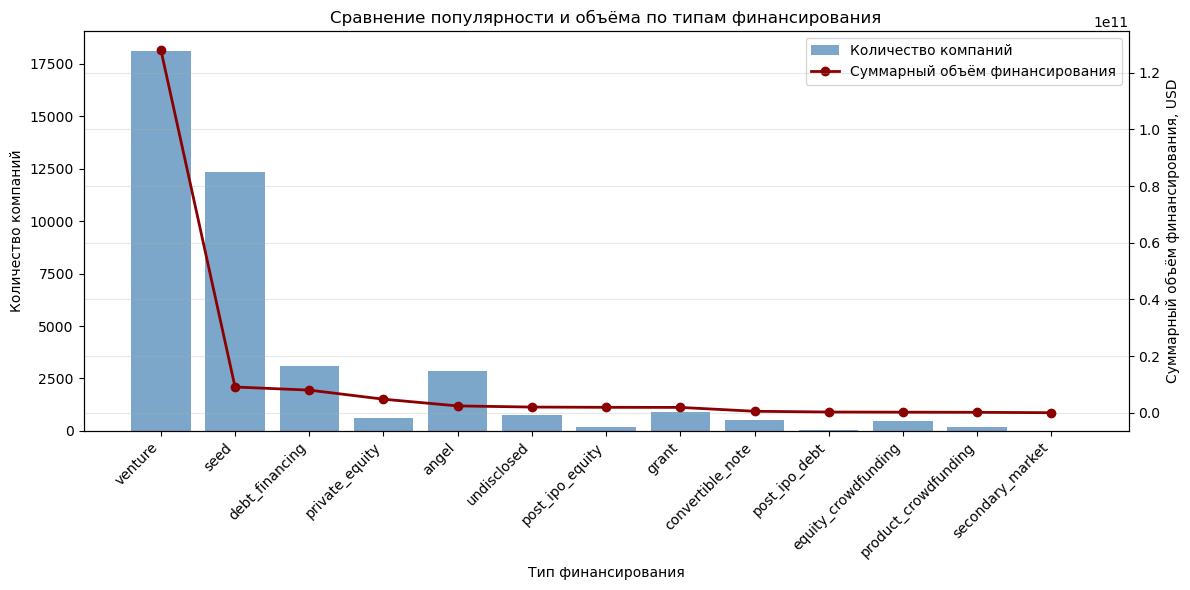

In [42]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Левая ось — популярность (количество компаний)
ax1.bar(
    funding_compare.index,
    funding_compare['companies_count'],
    color='steelblue',
    alpha=0.7,
    label='Количество компаний'
)
ax1.set_xticks(range(len(funding_compare.index)))
ax1.set_xticklabels(funding_compare.index, rotation=45, ha='right')

ax1.set_ylabel('Количество компаний')
ax1.set_xlabel('Тип финансирования')
ax1.tick_params(axis='y')
ax1.set_xticklabels(funding_compare.index, rotation=45, ha='right')

# Правая ось — суммарный объём финансирования
ax2 = ax1.twinx()
ax2.plot(
    funding_compare.index,
    funding_compare['total_funding'],
    color='darkred',
    marker='o',
    linewidth=2,
    label='Суммарный объём финансирования'
)

ax2.set_ylabel('Суммарный объём финансирования, USD')
ax2.tick_params(axis='y')

# Заголовок и легенда
plt.title('Сравнение популярности и объёма по типам финансирования')

# Общая легенда
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Venture**
* Самый массовый тип финансирования по количеству компаний.
* Формирует наибольший суммарный объём привлечённых средств.
* Лидер по суммарным возвратам за период.

**Seed**
* Второй по популярности тип финансирования.
* Объёмы финансирования и возвратов относительно невелики.
* Высокая популярность не сопровождается сопоставимыми возвратами.

**Angel**
* Используется реже, чем seed и venture.
* Небольшие объёмы финансирования и возвратов.

**Debt financing**
* Умеренная популярность по числу компаний.
* Существенные объёмы финансирования и заметные суммарные возвраты.
* Менее массовый, но более капиталоёмкий тип финансирования.

**Private equity**
* Используется относительно редко.
* Высокие объёмы финансирования на одну компанию.
* Значительные суммарные возвраты.

**Post-IPO equity / Post-IPO debt**
* Наименее популярные типы финансирования.
* Высокие объёмы на отдельные сделки.

**Grant**
* Используется достаточно часто.
* Возвраты отсутствуют или минимальны.

**Equity crowdfunding / Product crowdfunding / Secondary market**
* Низкая популярность и небольшие объёмы финансирования.
* Незначительные суммарные возвраты.

**Общие закономерности**
* Популярность типа финансирования не всегда коррелирует с его суммарным объёмом.
* Ранние стадии (seed, angel) — массовые, но с небольшими чеками.
* Поздние стадии (private equity, debt) — редкие, но капиталоёмкие.
* Venture финансирование занимает центральное положение, сочетая масштаб и массовость.

## Шаг 4. Анализ динамики

### 4.1 Динамика предоставления финансирования по годам

На данном этапе планируется проанализировать динамику предоставления финансирования стартапам по годам. Для этого для каждой компании будет рассчитан средний объём одного раунда финансирования на основе общего объёма привлечённых средств и количества раундов.

Далее на агрегированных данных будут построены графики, отражающие изменение типичного размера финансирования в рамках одного раунда, а также динамику общего количества раундов финансирования по годам как показателя инвестиционной активности на рынке.

In [43]:
funding_dynamics = (
    cb_filtered
    # средний размер одного раунда
    .assign(avg_round_usd=lambda x: x['funding_total_usd'] / x['funding_rounds'])
    # год финансирования
    .assign(funding_year=lambda x: x['mid_funding_at'].dt.year)
    # на всякий случай убираем строки без года и с нулевыми раундами
    .query('funding_rounds > 0')
    .dropna(subset=['funding_year'])
    # агрегация по годам
    .groupby('funding_year', as_index=False)
    .agg(
        avg_round_usd=('avg_round_usd', 'median'),   # типичный размер раунда
        funding_rounds=('funding_rounds', 'sum')     # общее число раундов
    )
    .sort_values('funding_year')
)

funding_dynamics

,funding_year,avg_round_usd,funding_rounds
0,2000,2460000.0,109.0
1,2001,2368582.0,58.0
2,2002,3616666.666667,97.0
3,2003,1521966.1,120.0
4,2004,3375000.0,169.0
5,2005,4628875.0,931.0
6,2006,3960000.0,1825.0
7,2007,2900000.0,2820.0
8,2008,2250000.0,3624.0
9,2009,1583333.333333,4472.0


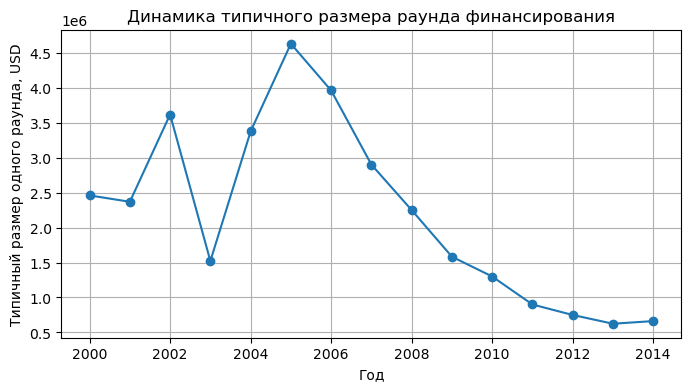

In [44]:
plt.figure(figsize=(8, 4))

plt.plot(
    funding_dynamics['funding_year'],
    funding_dynamics['avg_round_usd'],
    marker='o'
)

plt.xlabel('Год')
plt.ylabel('Типичный размер одного раунда, USD')
plt.title('Динамика типичного размера раунда финансирования')
plt.grid(True)

plt.show()

Типичный размер раунда (медиана среднего раунда по компаниям) рос в начале 2000-х и достиг пика в 2005 году (около 4,5 млн USD), после чего началось устойчивое снижение.

С 2006–2007 годов наблюдается нисходящий тренд: типичный размер одного раунда постепенно уменьшается и к 2012–2014 годам стабилизируется на уровне ~0,6–0,7 млн USD.

В 2014 году типичный размер раунда чуть выше, чем в 2013, но остаётся существенно ниже уровней середины 2000-х — рост активности происходит не за счёт крупных чеков.

Сопоставляя с количеством раундов, можно сделать вывод, что рынок становится более массовым: раундов больше, но средний чек меньше, что указывает на дробление инвестиций и более широкое распределение капитала между стартапами.

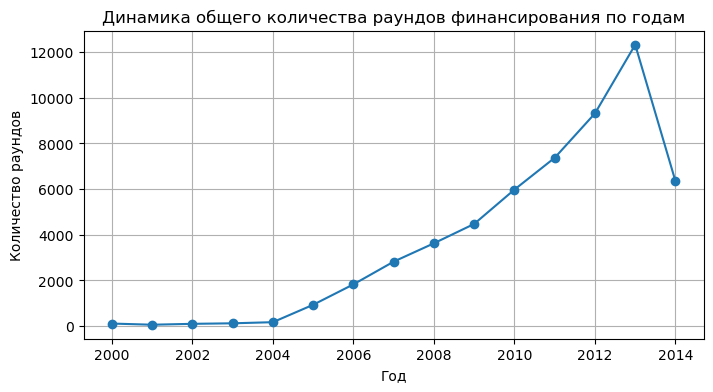

In [45]:
# Динамика общего количества раундов по годам
plt.figure(figsize=(8, 4))

plt.plot(
    funding_dynamics['funding_year'],
    funding_dynamics['funding_rounds'],
    marker='o'
)

plt.xlabel('Год')
plt.ylabel('Количество раундов')
plt.title('Динамика общего количества раундов финансирования по годам')
plt.grid(True)

plt.show()

Максимальный типичный размер одного раунда (медиана avg_round_usd) наблюдался в 2005 году, именно в этот год значение достигло наибольшего уровня за весь рассматриваемый период.

В 2014 году наблюдается следующая тенденция:

- общее количество раундов снизилось по сравнению с пиковыми значениями 2012–2013 годов, что указывает на ослабление инвестиционной активности;

- при этом типичный размер одного раунда стабилизировался и даже немного вырос относительно 2013 года, что может говорить о смещении фокуса инвесторов в сторону более крупных, но менее частых сделок.

### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

Составим сводную таблицу, в которой указывается суммарный размер общего финансирования `funding_total_usd` по годам и сегментам рынка. 

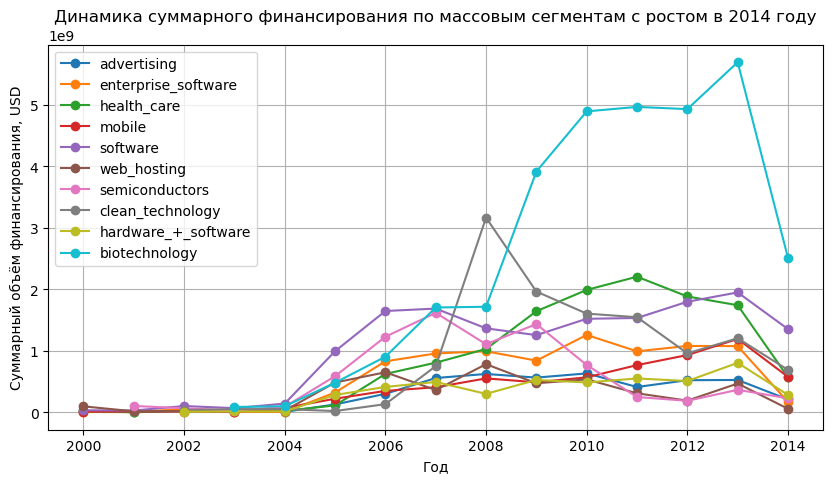

In [46]:

# 0) Год
cb_filtered['funding_year'] = pd.to_datetime(cb_filtered['mid_funding_at'], errors='coerce').dt.year

# 1) Сводная таблица: суммарное финансирование по годам и сегментам
funding_by_year_market = (
    cb_filtered
    .dropna(subset=['funding_year', 'market_raw'])
    .groupby(['funding_year', 'market_raw'], as_index=False)
    .agg(total_funding_usd=('funding_total_usd', 'sum'))
)

# 2) Сегменты с ростом в 2014 vs 2013 (как в принятом варианте)
funding_2013_2014 = funding_by_year_market[
    funding_by_year_market['funding_year'].isin([2013, 2014])
]

funding_pivot = (
    funding_2013_2014
    .pivot(index='market_raw', columns='funding_year', values='total_funding_usd')
)

funding_pivot = funding_pivot.dropna(subset=[2013, 2014])

growing_segments = funding_pivot[funding_pivot[2014] > funding_pivot[2013]]
growing_segments_list = growing_segments.index.tolist()

# 3) Массовые сегменты = ТОП-10 по сумме финансирования (как было)
mass_growing_segments = (
    funding_by_year_market
    .groupby('market_raw')['total_funding_usd']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

# 4) Данные для графика
funding_mass_growing = funding_by_year_market[
    funding_by_year_market['market_raw'].isin(mass_growing_segments)
].copy()

funding_mass_growing = funding_mass_growing[
    funding_mass_growing['market_raw'].notna() &
    (funding_mass_growing['market_raw'] != 'nan')
]

# 5) График
plt.figure(figsize=(10, 5))

for segment in funding_mass_growing['market_raw'].unique():
    segment_data = funding_mass_growing[funding_mass_growing['market_raw'] == segment]
    segment_data = segment_data.sort_values('funding_year')
    plt.plot(
        segment_data['funding_year'],
        segment_data['total_funding_usd'],
        marker='o',
        label=segment
    )

plt.xlabel('Год')
plt.ylabel('Суммарный объём финансирования, USD')
plt.title('Динамика суммарного финансирования по массовым сегментам с ростом в 2014 году')
plt.legend()
plt.grid(True)
plt.show()

In [47]:
# Сводная таблица: строки — год, столбцы — сегменты, значения — суммарное финансирование
funding_table = (
    funding_mass_growing
    .pivot_table(
        index='funding_year',
        columns='market_raw',
        values='total_funding_usd',
        aggfunc='sum'
    )
    .sort_index()
)

funding_table

market_raw,advertising,biotechnology,clean_technology,enterprise_software,hardware_+_software,health_care,mobile,semiconductors,software,web_hosting
funding_year,,,,,,,,,,
2000,14470000,<NA>,<NA>,4711445,<NA>,16000000,10000000,<NA>,31732640,95343090
2001,8778321,<NA>,<NA>,2180175,<NA>,125000,<NA>,101727992,27811352,15000000
2002,24500000,<NA>,34390435,52100995,8000000,20309671,11654597,<NA>,101026395,<NA>
2003,10500000,85531178,50352939,7669661,12200000,<NA>,8010058,28000000,66086037,<NA>
2004,6000000,97184859,50427954,4500000,14775000,22219087,69822132,88782797,140823795,27000000
2005,127196022,480063583,19420000,320413544,280865552,111091410,219894870,586220751,993076581,483332632
2006,299299458,903500543,131473889,828288298,411754024,623056656,347275817,1227940797,1646868624,649959267
2007,556704331,1704078338,749711239,955973554,492471382,806054641,405971659,1616604148,1686115571,361121449
2008,622673464,1716033000,3165808492,991664296,298931267,1029156722,550375090,1107199296,1365005648,781623731


Для анализа были отобраны массовые сегменты рынка, а также сегменты, показавшие рост суммарного финансирования в 2014 году по сравнению с 2013. Далее для каждого из них построена динамика изменения суммарного объёма финансирования по годам.

Анализ суммарного объёма финансирования по массовым сегментам показывает, что наиболее выраженный и масштабный рост в 2006–2013 годах демонстрирует biotechnology: сегмент быстро наращивает объёмы инвестиций, достигая пиковых значений в 2013 году, после чего в 2014 году наблюдается заметное снижение. Это указывает на высокую волатильность и зависимость от отдельных крупных сделок.

Clean technology также характеризуется резким ростом в 2008–2009 годах, однако далее объёмы финансирования снижаются, что говорит о менее устойчивом долгосрочном тренде.

Сегменты software, enterprise software и health care демонстрируют более плавный и устойчивый рост на протяжении длительного периода, с максимальными значениями в 2012–2013 годах и умеренной коррекцией в 2014 году. Их динамика выглядит менее подверженной резким скачкам по сравнению с биотехнологиями и «чистой» технологией.

Сегменты advertising, mobile и hardware + software показывают рост до начала 2010-х годов, после чего их объёмы финансирования стабилизируются или снижаются, что может свидетельствовать о насыщении рынка.

В целом результаты подтверждают, что быстрый рост суммарного финансирования в рассматриваемый период обеспечивается в первую очередь отдельными капиталоёмкими сегментами, тогда как наиболее устойчивую динамику демонстрируют крупные программные и медицинские направления.

### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

На этом этапе мы анализируем, какая доля привлечённых средств со временем возвращается инвесторам для разных типов финансирования. Для этого по каждому году и каждому типу финансирования рассчитывается нормированное значение возврата: отношение суммы возвращённых средств к суммарному объёму предоставленного финансирования. Чтобы избежать искажений, слишком большие аномальные значения заменяются на пропуски, а также учитывается защита от деления на ноль. Полученные показатели позволяют сравнить динамику возвратов между типами финансирования и выявить те из них, где рост показателя является наиболее устойчивым.

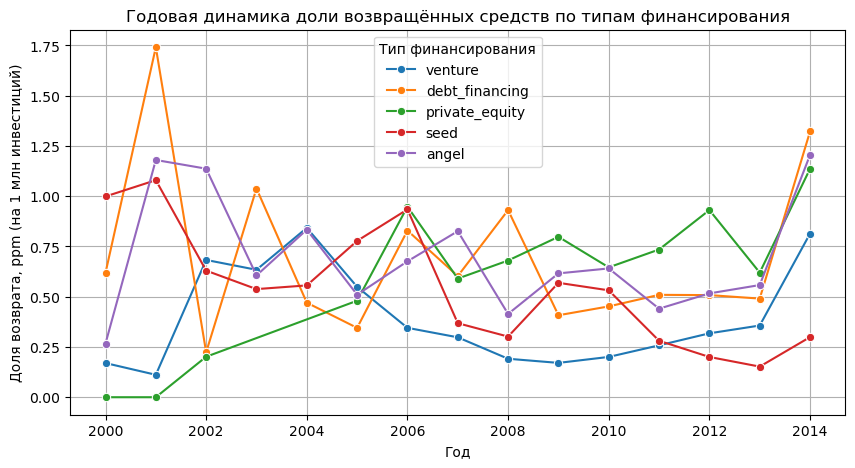

In [48]:
# Типы финансирования, которые нужны по заданию
target_types = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']

# 1) Считаем "предоставленное финансирование" по годам и типам (знаменатель)
#    Используем cb_filtered (после фильтраций), год берём из mid_funding_at
cb_filtered['funding_year'] = cb_filtered['mid_funding_at'].dt.year

funding_by_year = (
    cb_filtered
    .groupby('funding_year', as_index=False)[target_types]
    .sum()
    .rename(columns={'funding_year': 'year'})
)

# 2) Берём "возвраты" по годам и типам (числитель) из cb_returns
#    Если year уже индекс — превращаем индекс в колонку
returns_by_year = cb_returns.copy()
if returns_by_year.index.name == 'year':
    returns_by_year = returns_by_year.reset_index()

returns_by_year = returns_by_year[['year'] + target_types].copy()

# 3) Объединяем таблицы по year, чтобы посчитать нормированные значения (return / funding)
merged = funding_by_year.merge(returns_by_year, on='year', how='inner', suffixes=('_funding', '_returns'))

# 4) Считаем долю возврата по каждому типу финансирования
#    Добавляем 1e-60 к знаменателю, чтобы избежать деления на 0
eps = 1e-60

for t in target_types:
    merged[f'{t}_ratio'] = merged[f'{t}_returns'] / (merged[f'{t}_funding'] + eps)

# 5) Заменяем слишком большие аномальные значения на пропуски
#    (порог можно настроить, здесь берём разумный верхний предел = 10)
ratio_cols = [f'{t}_ratio' for t in target_types]
merged[ratio_cols] = merged[ratio_cols].mask(merged[ratio_cols] > 10)

# 6) Готовим данные для графика (long-формат)
ratio_long = merged[['year'] + ratio_cols].melt(
    id_vars='year',
    var_name='funding_type',
    value_name='return_ratio'
)

ratio_long['funding_type'] = ratio_long['funding_type'].str.replace('_ratio', '', regex=False)

# 6.1) Переводим долю в ppm (parts per million), чтобы убрать 1e-6 и сделать график читабельным
ratio_long['return_ratio_ppm'] = ratio_long['return_ratio'] * 1_000_000

# 7) Строим график: динамика нормированной доли возврата по годам
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=ratio_long,
    x='year',
    y='return_ratio_ppm',
    hue='funding_type',
    marker='o'
)

plt.xlabel('Год')
plt.ylabel('Доля возврата, ppm (на 1 млн инвестиций)')
plt.title('Годовая динамика доли возвращённых средств по типам финансирования')
plt.grid(True)
plt.legend(title='Тип финансирования')

plt.show()

Для корректной интерпретации показатель доли возвратов приведён к масштабу ppm (возвраты на 1 млн инвестиций). Это позволяет сопоставлять динамику при существенной разнице масштабов инвестиций и возвратов.

Наиболее устойчивую положительную динамику демонстрирует private equity: доля возвратов в целом растёт на протяжении рассматриваемого периода. Debt financing также показывает рост к концу периода, но с более высокой волатильностью.

Для venture и angel характерна умеренная и менее стабильная динамика, а seed финансирование демонстрирует снижение доли возвратов в долгосрочной перспективе, что может быть связано с более высоким уровнем риска ранних стадий и особенностями данных.

В целом, различия в динамике отражают специфику типов финансирования и не могут напрямую интерпретироваться как различия в эффективности без учёта инвестиционного горизонта и структуры сделок.


## Шаг 5. Итоговый вывод и рекомендации

### Рекомендации заказчику (на 2015 год)
### В какие отрасли целесообразно инвестировать

С учётом динамики **суммарного объёма финансирования**, устойчивости роста в массовых сегментах рынка, а также анализа распределения объёмов инвестиций и доли выбросов по сегментам, наиболее перспективными направлениями для инвестиций выглядят технологические и цифровые отрасли, прежде всего **software, enterprise software, Internet / SaaS и health care**.

Эти сегменты демонстрируют:
- стабильный рост объёмов финансирования на протяжении длительного периода;
- высокую инвестиционную активность;
- широкую базу компаний, за счёт чего рост в меньшей степени зависит от единичных крупных сделок.

Дополнительный анализ распределения общего объёма финансирования и доли выбросов по сегментам `market` показывает, что в капиталоёмких направлениях (таких как biotechnology или clean technology) динамика часто определяется отдельными крупными сделками и характеризуется высокой волатильностью. В то же время массовые технологические сегменты демонстрируют более устойчивую и предсказуемую динамику, что снижает инвестиционные риски.

**Вывод:** в 2015 году приоритет целесообразно отдавать массовым технологическим и цифровым сегментам с устойчивым долгосрочным ростом.

---

### Какой тип финансирования наиболее уместен

С учётом структуры рынка, устойчивости массовых сегментов и различий в динамике доли возвратов по типам финансирования, анализ объёмов инвестиций, популярности типов сделок и показателей возвратов выявляет следующие особенности:

- **Venture financing** является наиболее массовым и универсальным инструментом, подходящим для инвестиций в быстрорастущие технологические рынки и компании на ранних и средних стадиях развития.
- **Private equity** демонстрирует более устойчивую динамику доли возвратов, однако применяется реже и ориентирован преимущественно на зрелые компании, что ограничивает его применимость для стратегий активного роста.
- **Debt financing** может обеспечивать рост возвратов, но характеризуется повышенной волатильностью и чувствительностью к отдельным сделкам и рыночным условиям.

**Вывод:**
- для стратегии роста и масштабирования целесообразно использовать **venture financing**;
- для более консервативной стратегии с фокусом на устойчивость возвратов — **private equity**.

### Итоги проекта

***Какие шаги были выполнены***

В рамках проекта был проведён полный цикл аналитической работы с данными о венчурном финансировании:

1.  **Предобработка данных**

- Привели текстовые поля (market, name) к единому формату.
- Зафиксировали исходные значения сегментов рынка в отдельном столбце (market_raw), чтобы избежать потери информации.
- Обработали пропуски и проверили дубликаты компаний.

2. **Инженерия признаков и сегментация рынка**

- Сегменты рынка были классифицированы на mass / mid / niche по количеству компаний.
- Для дальнейшего анализа использовались как исходные сегменты (market_raw), так и укрупнённые категории (market_group).

3. **Анализ распределений и выбросов**

- Исследовано распределение общего объёма финансирования.
- Выбросы определялись методом IQR отдельно по каждому сегменту, что позволило корректно учитывать специфику рынка.
- Компании с аномальными значениями были исключены из дальнейшего анализа.
- Проверка полноты данных и фильтрация периода
- Проанализирована инвестиционная активность по годам.
- Выявлено, что репрезентативные данные начинаются с лет, где зафиксировано не менее 50 раундов.
- Дальнейший анализ выполнялся только по этим «активным» годам.

4. **Анализ динамики рынка**

- Изучена динамика типичного размера раунда и общего количества раундов по годам.
- Построена динамика суммарного финансирования по массовым сегментам, показавшим рост в 2014 году.
- Проанализированы типы финансирования по объёму, популярности и устойчивости возвратов.
- Анализ возвратов средств
- Рассчитана нормированная доля возвратов по годам и типам финансирования.
- Исключены аномальные значения возвратов.
- Оценена устойчивость роста показателя по ключевым типам финансирования.

### Основные выводы проекта

В рамках проекта был проведён анализ инвестиционной активности стартапов с фокусом на объёмы финансирования, структуру рынка по сегментам и типам финансирования, а также динамику ключевых показателей во времени. Анализ основывался на агрегированных данных и был направлен на выявление общерыночных закономерностей, а не поведения отдельных сделок.

Первичный анализ структуры рынка показал высокую концентрацию капитала: значительная часть суммарного объёма финансирования приходится на ограниченное число массовых сегментов. Для снижения фрагментации данных и упрощения дальнейшего анализа реальные сегменты рынка были укрупнены в рамках столбца market: для массовых сегментов сохранены их исходные названия, тогда как менее представленные сегменты агрегированы в категории mid и niche. Такое преобразование позволило сохранить детализацию для ключевых рынков и одновременно корректно учитывать вклад средних и нишевых направлений.

Анализ распределения общего объёма финансирования по категориям market показал, что наиболее высокие медианные значения и наибольший разброс объёмов инвестиций наблюдаются в ряде массовых сегментов, прежде всего biotechnology, health care, software, enterprise software и clean technology. Эти сегменты играют ключевую роль в формировании суммарного объёма рынка. В то же время категории mid и niche характеризуются более низкими типичными объёмами финансирования и меньшей вариативностью, что отражает ограниченный масштаб инвестиционной активности в данных группах.

Анализ временной динамики суммарного финансирования выявил, что рост рынка распределён неравномерно. В отдельные периоды резкое увеличение объёмов инвестиций обеспечивается капиталоёмкими сегментами, такими как biotechnology и clean technology, динамика которых отличается высокой волатильностью и зависимостью от отдельных крупных сделок. Одновременно сегменты, связанные с программным обеспечением и здравоохранением (software, enterprise software, health care), демонстрируют более плавный и устойчивый рост, что указывает на их системную роль в долгосрочном развитии рынка.

Отдельное внимание было уделено сегментам, показавшим рост суммарного финансирования в 2014 году по сравнению с 2013 годом. Результаты анализа подтверждают, что восстановление и дальнейший рост рынка после кризисных периодов в первую очередь обеспечиваются крупными и уже сформировавшимися сегментами, обладающими устойчивым спросом со стороны инвесторов.

Дополнительный анализ структуры финансирования по типам показал существенные различия в динамике доли возвращённых средств. Абсолютные значения доли возвратов оказались крайне малы по отношению к общему объёму инвестиций, что обусловлено редкостью exit-событий и неполнотой данных о возвратах. Для корректной интерпретации показатель был приведён к масштабу ppm (возвраты на 1 млн инвестиций), что позволило наглядно сравнить динамику между типами финансирования. Результаты показали, что private equity характеризуется более стабильной динамикой доли возвратов, тогда как venture и angel финансирование отличаются большей неопределённостью и отсутствием выраженного долгосрочного тренда. Seed-финансирование демонстрирует снижение доли возвратов в долгосрочной перспективе, что отражает высокий уровень риска инвестиций на ранних стадиях.

Анализ доли выбросов по сегментам market показал, что наибольшая относительная доля аномально крупных сделок наблюдается в ряде массовых сегментов, таких как real estate, entertainment, consulting, search и cloud computing. Это указывает на высокую неоднородность распределения объёмов финансирования внутри данных сегментов и заметное влияние отдельных крупных сделок на общую структуру рынка. При этом для агрегированной категории niche доля выбросов сопоставима с отдельными массовыми сегментами, что отражает высокую фрагментированность и вариативность инвестиционной активности в нишевых рынках.

В целом проведённый анализ подтверждает, что рынок стартап-инвестиций является неоднородным как по сегментам, так и по типам финансирования. Быстрый рост суммарных объёмов инвестиций обеспечивается ограниченным числом капиталоёмких направлений, тогда как устойчивость и предсказуемость динамики характерны прежде всего для зрелых массовых сегментов. Полученные выводы создают основу для дальнейшего более детального анализа эффективности инвестиций с учётом инвестиционного горизонта, структуры сделок и стадии развития компаний.

### Согласованность выводов и ограничения анализа

Все ключевые выводы логически согласуются между собой: рост рынка, снижение типичного размера раунда и увеличение количества сделок отражают структурные изменения венчурной индустрии.

Результаты по динамике финансирования и возвратов взаимно подтверждают вывод о переходе к более зрелому и диверсифицированному рынку.

Ограничения анализа:

- возможная неполнота данных за последние годы периода;

- высокая чувствительность показателей возвратов к выбросам, требующая аккуратной интерпретации;

- анализ основан на исторических данных и не учитывает внешние макроэкономические факторы.